In [2]:
import numpy as np
from tqdm import tqdm
import time
import datetime 
import pickle
import matplotlib.pyplot as plt

In [3]:
freq2 = (0.5e9, 1.2e9, 5e6)
freq_drive_secondary = np.arange(freq2[0],freq2[1],freq2[2])
power_secondary = 15# 7

mw_source_smb.pulse_modulation(True)
odmr_counter_interfuse.secondary_source_duty_cycle = 0.5

print("Length of secondary freq. axis: ", len(freq_drive_secondary), "points")
print("Power of secondary freq.: ", power_secondary, "dBm")

#ODMR PARAMETERS DEFINED IN ODMR MODULE
freq_start, freq_stop, freq_step = (odmrlogic.mw_starts[0], odmrlogic.mw_stops[0], odmrlogic.mw_steps[0])
power = odmrlogic.sweep_mw_power 
channel = 0

runtime = odmrlogic.run_time #in s
tag0 = f'Sec_drive_array(start,stop,step)_{freq2}_'
tag1 = "OOC_1µm_50perc_dutycycle"
tag = tag0+tag1
print(tag)

Length of secondary freq. axis:  140 points
Power of secondary freq.:  15 dBm
Sec_drive_array(start,stop,step)_(500000000.0, 1200000000.0, 5000000.0)_OOC_1µm_50perc_dutycycle


## Measurement loop - 01

In [24]:
xy_data = np.zeros((len(freq_drive_secondary), 1, odmrlogic.odmr_plot_x.size))
odmrlogic.stop_jupyter_meas = False
save_data = {}

for i, freq in tqdm(enumerate(freq_drive_secondary)):
    mw_source_smb.set_cw(freq, power_secondary)
    mw_source_smb.cw_on()
    
    x_axis, data, fit_params = odmrlogic.perform_odmr_measurement([freq_start], [freq_step], [freq_stop], power, channel, runtime,
                                                                  fit_function='No Fit', save_after_meas=False, name_tag=tag)
    xy_data[i][0] = data
    y_axis = data.reshape((1, odmrlogic.odmr_plot_x.size))
    odmrlogic.sigOdmrPlotsUpdated.emit(odmrlogic.odmr_plot_x, y_axis, xy_data)
    if odmrlogic.stop_jupyter_meas:
        print('Measurement force stopped!')
        break

mw_source_smb.off()
odmrlogic.odmr_plot_y = y_axis
odmrlogic.odmr_plot_xy = xy_data
spm.retract_probe()

save_data['XY'] = xy_data[:,0,:]
save_data['Secondary drive'] = freq_drive_secondary
save_data['Primary drive'] = odmrlogic.odmr_plot_x
save_data['Secondary power (dBm)'] = power_secondary
save_path0 = odmrlogic.savelogic().get_path_for_module('Non-Linear-Drive')
save_path = save_path0 + r"\\" + '{date:%d-%m-%Y_%H-%M-%S}_'.format(date=datetime.datetime.now()) + tag1 + ".pickle"

with open(save_path, 'wb') as handle:
    pickle.dump(save_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

if not odmrlogic.stop_jupyter_meas:
    odmrlogic.save_odmr_data(tag=tag)

140it [1:10:54, 30.39s/it]


In [107]:
mw_source_smb.pulse_modulation(False)
odmr_counter_interfuse.secondary_source_duty_cycle = 0.5
mw_source_smb.set_cw(3.615e9, 15)
mw_source_smb.cw_on()

0

In [108]:
mw_source_smb.off()

0

In [97]:
mw_source_smr.set_cw(3.615e9, 15)

(3615000000.0, 15.0, 'cw')

In [103]:
mw_source_smr.cw_on()

0

In [106]:
mw_source_smr.off()

0

# Measurement loop - 02 Power sweep

In [65]:
x_axis, data, fit_params = odmrlogic.perform_odmr_measurement([freq_start], [freq_step], [freq_stop], '0', channel, runtime,fit_function='No Fit', save_after_meas=False, name_tag=tag)

In [108]:
freq2 = 0.54e9
freq1_range = (3.34e9,3.47e9,1e6)

power = (1, 16, 4) # power in dBm for primary start,stop,step
pow_drive_primary = np.arange(power[0],power[1],power[2])

power = (1, 16, 2) # power in dBm for secondary start,stop,step
pow_drive_secondary = np.arange(power[0],power[1],power[2])

mw_source_smb.pulse_modulation(True)
odmr_counter_interfuse.secondary_source_duty_cycle = 0.5


#ODMR PARAMETERS DEFINED IN ODMR MODULE
freq_start, freq_stop, freq_step = freq1_range
channel = 0

runtime = 20 #in s
tag1 = "OOC_1µm_50perc_dutycycle_powersweep"
tag = tag1
print(tag)
print(f"Min runtime: {(runtime*len(pow_drive_primary)*len(pow_drive_secondary))/60/60}hours")

OOC_1µm_50perc_dutycycle_powersweep
Min runtime: 0.17777777777777776hours


In [106]:
pow_drive_primary

array([ 1,  5,  9, 13])

In [109]:
pow_drive_secondary

array([ 1,  3,  5,  7,  9, 11, 13, 15])

In [105]:
odmrlogic.stop_jupyter_meas = False
save_data = {}
save_data['Secondary power drive'] = pow_drive_secondary
save_data['Primary power drive'] = pow_drive_primary
save_data['Secondary freq (Hz)'] = freq2
freq_range = np.arange(freq_start, freq_stop, freq_step)
all_data = np.zeros((len(pow_drive_primary), len(pow_drive_secondary), len(freq_range)-1))

for i, pow1 in tqdm(enumerate(pow_drive_primary)):
    xy_data = np.zeros((len(freq_drive_secondary), 1, odmrlogic.odmr_plot_x.size))
    for j, pow2 in enumerate(pow_drive_secondary):
        mw_source_smb.set_cw(freq2, pow2)
        mw_source_smb.cw_on()
        x_axis, data, fit_params = odmrlogic.perform_odmr_measurement([freq_start], [freq_step], [freq_stop], float(pow1), channel, runtime,
                                                                      fit_function='No Fit', save_after_meas=False, name_tag=tag)
        all_data[i,j,:] = data
        
        xy_data[j][0] = data
        y_axis = data.reshape((1, odmrlogic.odmr_plot_x.size))
        odmrlogic.sigOdmrPlotsUpdated.emit(odmrlogic.odmr_plot_x, y_axis, xy_data)
        if odmrlogic.stop_jupyter_meas:
            print('Measurement force stopped!')
            break
    save_data['XY'] = xy_data[:,0,:]
    if odmrlogic.stop_jupyter_meas:
        print('Measurement force stopped!')
        break
    
save_data['Data'] = all_data
save_data['Primary freq drive (Hz)'] = odmrlogic.odmr_plot_x

# spm.retract_probe()
mw_source_smb.off()    
save_path0 = odmrlogic.savelogic().get_path_for_module('Non-Linear-Drive')
save_path = save_path0 + r"\\" + '{date:%d-%m-%Y_%H-%M-%S}_'.format(date=datetime.datetime.now()) + tag1 + ".pickle"

with open(save_path, 'wb') as handle:
    pickle.dump(save_data, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
spm.retract_probe()

4it [13:49, 207.50s/it]


True

# Measurement loop - 03 2D AFM scan with microwave on/off at each point

In [ ]:
 #prepare spm qudi for the measurement
    afm_scanner_logic._qafm_scan_array = image_dict
    qafm_gui.adjust_qafm_image()
    
    for idy, y_pos in enumerate(tqdm(scan_array_y)):
        for idx, x_pos in enumerate(scan_array_x):
            
            #Pause measurement if true
            while afm_scanner_logic.jupyter_meas_pause:
                time.sleep(0.5)
            
            #Move to new pixel position
            while True:
                if spm._dev.base.getParameter(spm._dev.base.getConst('ID_SCAN_STATUS'), 0)==2:
                    time.sleep(0.001)
                else:
                    break
            afm_scanner_logic.set_afm_pos({'x':x_pos, 'y':y_pos})
            time.sleep(0.001)
            while True:
                if spm._dev.base.getParameter(spm._dev.base.getConst('ID_SCAN_STATUS'), 0)==2:
                    time.sleep(0.001)
                else:
                    break
            
            #Measure Topography
            topo = 0
            for i in range(5):
                topo =+ spm.get_sample_pos()['Z']
                time.sleep(0.005)
            topography[idy, idx] = topo_z_limit - topo/5
            
            #Measure NV CW counts
            afm_scanner_logic._counter._tagger.sync()
            t_int = 5 # time for integration in ms 
            afm_scanner_logic._counter.countrate.startFor(int(t_int*1e9), clear = True)
            afm_scanner_logic._counter.countrate.waitUntilFinished(timeout=int(t_int*20))
            counts[idy, idx] = np.nan_to_num(afm_scanner_logic._counter.countrate.getData())[0]
            
            #Measure resonance frequency with tracking mode
            change_freq = False
            if idx == 0 and idy != 0:
                res_freq_used = res_freq[idy-1,idx]
                change_freq = True
            
            elif idx == 0 and idy == 0:
                res_freq_used = init_res_freq
                change_freq = True
            
            for i in range(tracking_repetitions):
                tracking_result = run_measurement(tracking_AWG_ensemble_list, tracking_PS_seq_name, tracking_tau_arr, tracking_alternating, tracking_freq_sweep, res_freq_used, power, max_sweeps_tracking, upload = False if i>0 else True, change_freq = change_freq)
                res_freq[idy, idx], vis = tracking_analysis(tracking_result, slope, res_freq_used)
                res_freq_used = res_freq[idy, idx]
                change_freq = True
            
            #Measure T2 reference signal C0
            T2_ref_raw[idy, idx], T2_ref_raw_alt[idy, idx], T2_ref[idy, idx] = run_measurement(echo_ref_AWG_ensemble_list, echo_ref_PS_seq_name, echo_ref_tau_arr, echo_ref_alternating, echo_ref_freq_sweep, res_freq_used, power, max_sweeps_T2, upload = True, change_freq = True)
            
            #Measure T2 signal CS
            T2_sig_raw[idy, idx], T2_sig_raw_alt[idy, idx], T2_sig[idy, idx] = run_measurement(echo_sig_AWG_ensemble_list, echo_sig_PS_seq_name, echo_sig_tau_arr, echo_sig_alternating, echo_sig_freq_sweep, res_freq_used, power, max_sweeps_T2, upload = True, change_freq = False)
            
            #Update image in qudi spm modul
            image_dict['Height(Dac)_fw']['data'] = topography
            image_dict['counts_fw']['data'] = counts
            image_dict['fit_param_fw']['data'] = res_freq
            image_dict['fit_param_bw']['data'] = T2_ref
            image_dict['b_field_fw']['data'] = T2_sig/T2_ref
            
            afm_scanner_logic._qafm_scan_array = image_dict
            afm_scanner_logic.sigQAFMLineScanFinished.emit()
            
            if afm_scanner_logic.jupyter_meas_stop:
                break
        
        #run save routine end of every fast axis loop

        meas_dict['topo']['data'] = topography
        meas_dict['counts']['data'] = counts
        meas_dict['res_freq']['data'] = res_freq
        meas_dict['T2_ref']['data'] = T2_ref
        meas_dict['T2_ref_raw']['data'] = T2_ref_raw
        meas_dict['T2_ref_raw_alt']['data'] = T2_ref_raw_alt
        meas_dict['T2_sig']['data'] = T2_sig
        meas_dict['T2_sig_raw']['data'] = T2_sig_raw
        meas_dict['T2_sig_raw_alt']['data'] = T2_sig_raw_alt
        meas_dict['T2_sig_corr']['data'] = T2_sig/T2_ref


        #write temporary file fro gwyddion here
        with open(path+'.pickle', 'wb') as f:
            pickle.dump(meas_dict, f)

        save_obj_to_gwyddion(dataobj=meas_dict,filename=path+'.gwy')
        
        if afm_scanner_logic.jupyter_meas_stop:
            print('Measurement force stopped')
            break
        

    
    #Activate the printing of information into the manager log again
    awg_spectrum.print_log_info = True
    sequencegeneratorlogic_AWG.print_log_info = True
    sequencegeneratorlogic.print_log_info = True
    awg_spectrum.pulser_off()
    mw_source_smbv.off()
    mw_source_sgs.off()
    
    return meas_dict

Data analysis

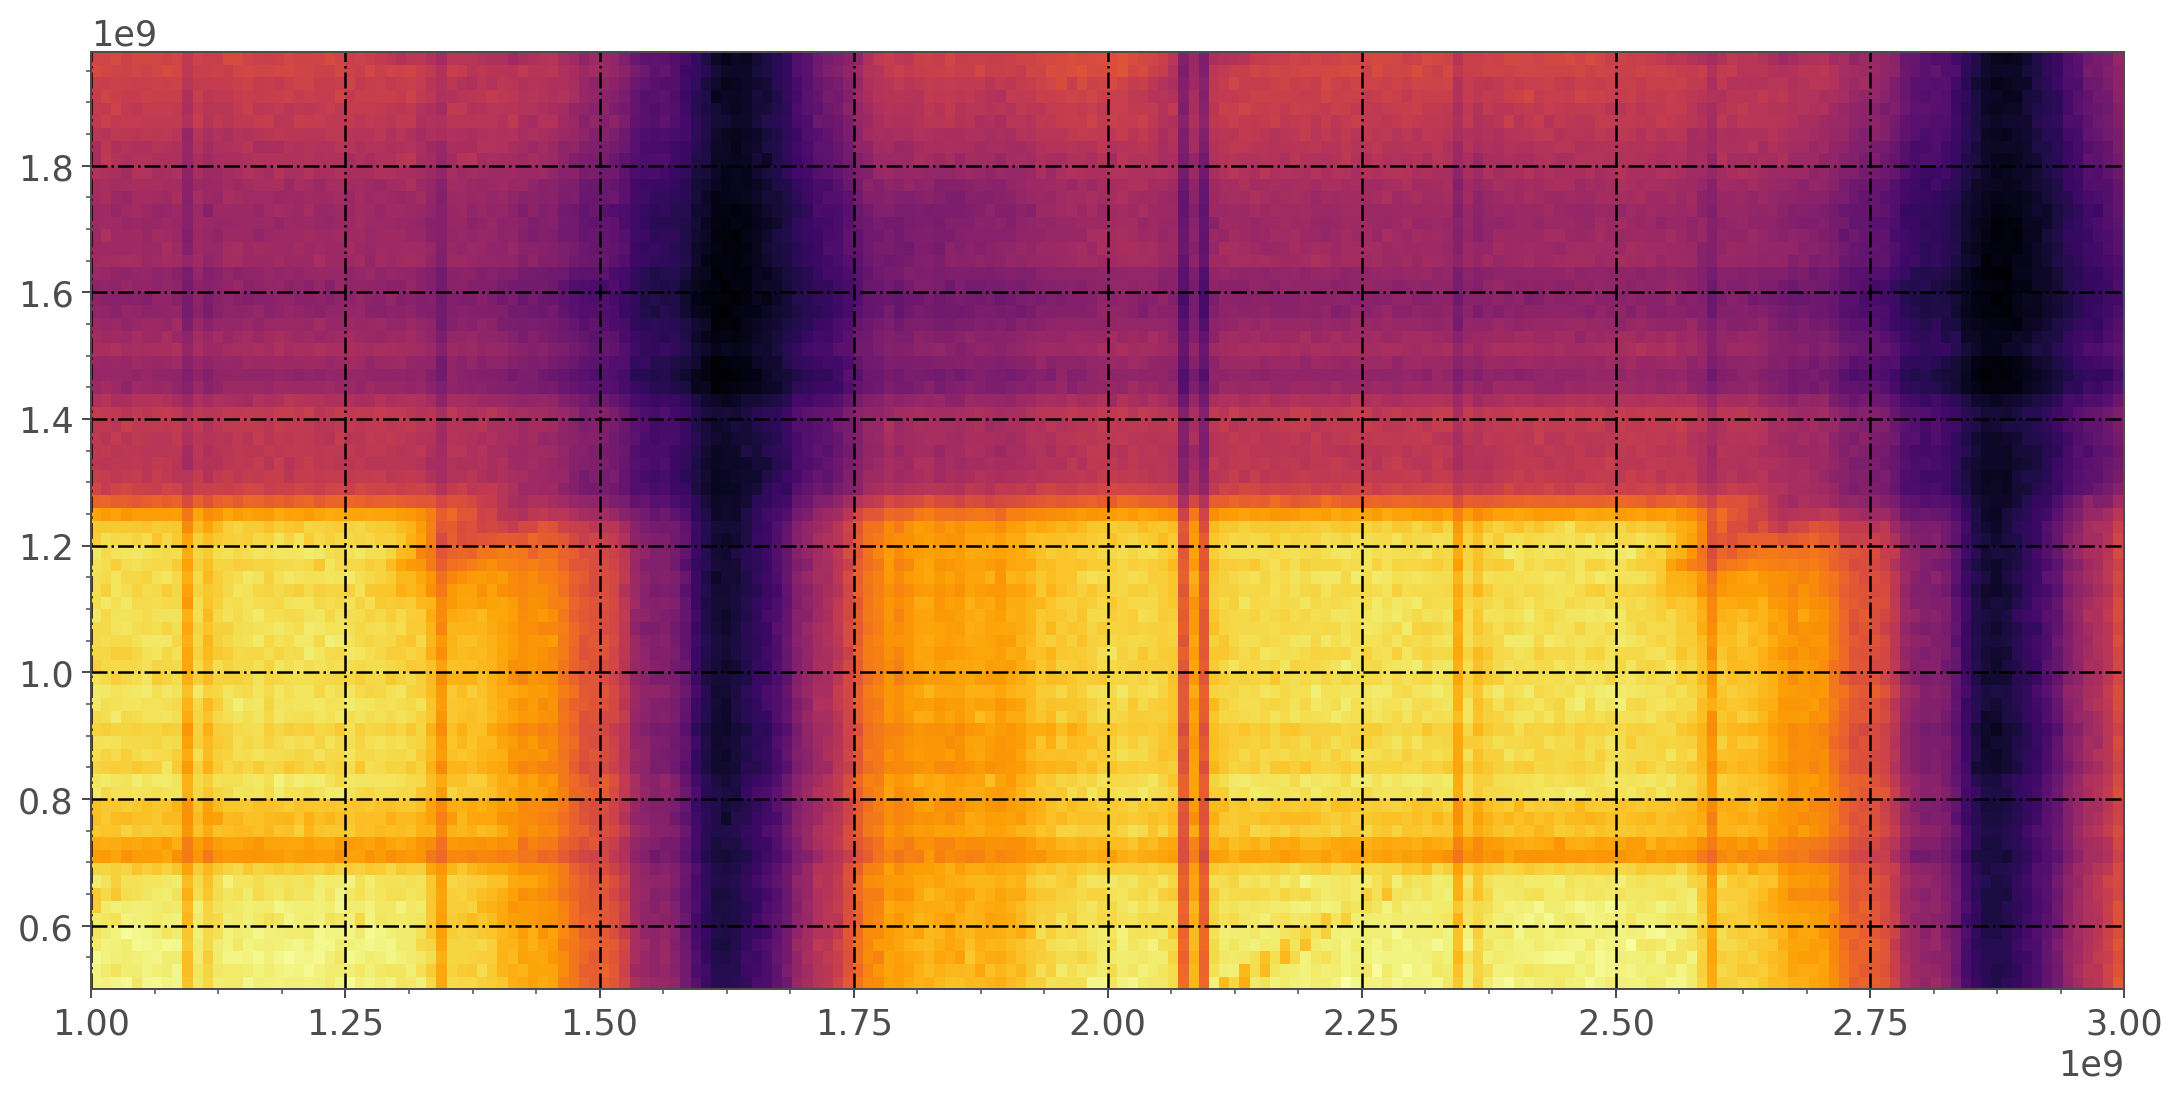

In [57]:
root = r"D:\Data\RT_AFM_Data\2024\11\20241111\Non-Linear-Drive"
data_path = root + r"\\" + r"11-11-2024_16-00-28_OOC.pickle"

with open(data_path, 'rb') as handle:
    parent_data = pickle.load(handle)

data = parent_data['XY']
x = parent_data["Primary drive"]
y = parent_data["Secondary drive"]
import matplotlib.pyplot as plt

fig, ax = plt.subplots(constrained_layout=True)
ax.pcolormesh(x,y,data, cmap="inferno")
ax.grid(color='black', linestyle='-.', linewidth=1)
ax.set_xtitle=("f in GHz")
ax.set_ylabel=('f in GHz')
plt.show()

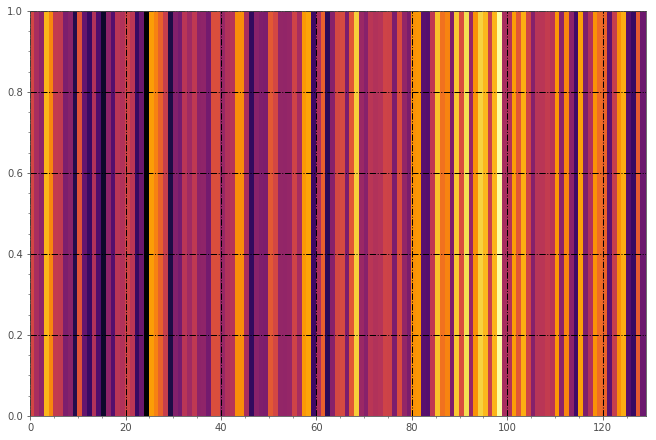

In [58]:
root = r"D:\Data\RT_AFM_Data\2024\11\20241118\Non-Linear-Drive"
data_path = root + r"\\" + r"18-11-2024_13-26-18_OOC_1µm_50perc_dutycycle_powersweep.pickle"

with open(data_path, 'rb') as handle:
    parent_data = pickle.load(handle)

data = parent_data["Data"][1,:,:]
x = parent_data['Primary freq drive (Hz)']
y = parent_data['Secondary power drive']


fig, ax = plt.subplots(constrained_layout=True)
ax.pcolormesh(data, cmap="inferno")
ax.grid(color='black', linestyle='-.', linewidth=1)
ax.set_xtitle=("f in GHz")
ax.set_ylabel=('f in GHz')
plt.show()

In [56]:
y

array([15])